## Explainable EEG FriendPattern Prediction Model

In [22]:
# Import libraries
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import NeighborhoodComponentsAnalysis as NCA, KNeighborsClassifier
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.pipeline import Pipeline 
from sklearn.metrics import (accuracy_score, precision_score, confusion_matrix, recall_score, f1_score, confusion_matrix, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
# Combine samples from differenent subjects into a single dataset
path = "C:\\Users\\Sikhulile\\Downloads\\Dataframe classified Epilepsy data"

combined_data = pd.DataFrame()
for file in os.listdir(path):
        data = pd.read_csv(os.path.join(path, file))
        if combined_data.empty:
            combined_data = data
        else:
            combined_data = pd.concat([combined_data, data], ignore_index=True)
print("Combined data shape:", combined_data.shape)

# Prepare X and Y values 
X = np.asarray(combined_data.drop('class', axis=1))
Y = np.asarray(combined_data['class'])

#Preprocessing the data
X = preprocessing.StandardScaler().fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 

Combined data shape: (488, 631)


Start index: 314, Stop index: 629
Training KNN with 314 features...
Mean accuracy for 314 features: 0.9769
Training KNN with 315 features...
Mean accuracy for 315 features: 0.9769
Training KNN with 316 features...
Mean accuracy for 316 features: 0.9769
Training KNN with 317 features...
Mean accuracy for 317 features: 0.9769
Training KNN with 318 features...
Mean accuracy for 318 features: 0.9769
Training KNN with 319 features...
Mean accuracy for 319 features: 0.9769
Training KNN with 320 features...
Mean accuracy for 320 features: 0.9769
Training KNN with 321 features...
Mean accuracy for 321 features: 0.9769
Training KNN with 322 features...
Mean accuracy for 322 features: 0.9769
Training KNN with 323 features...
Mean accuracy for 323 features: 0.9769
Training KNN with 324 features...
Mean accuracy for 324 features: 0.9769
Training KNN with 325 features...
Mean accuracy for 325 features: 0.9769
Training KNN with 326 features...
Mean accuracy for 326 features: 0.9769
Training KNN with

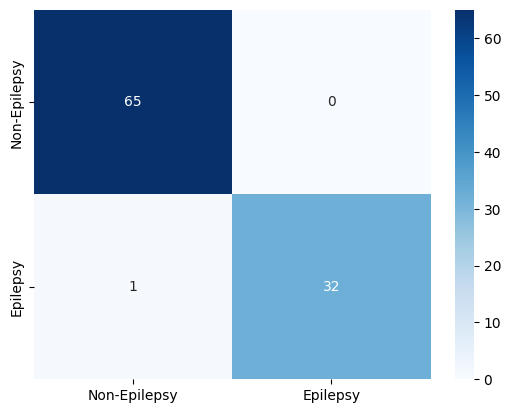

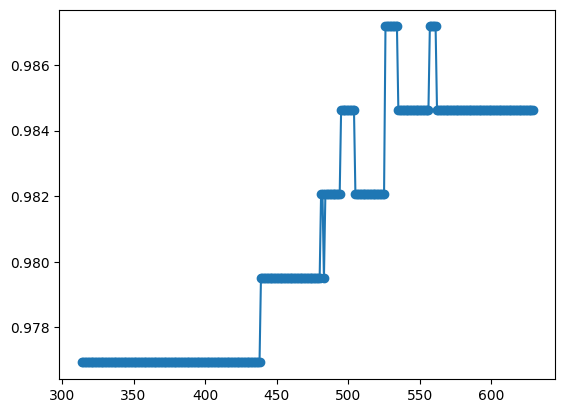

In [ ]:
# Instantiate the NCA model
nca = NCA(random_state=6)
nca_fit = nca.fit(X_train, Y_train)
# Importance weights of the features
t1 = 0.5
t2 = 0.9999
feature_weights = np.linalg.norm(nca_fit.components_, axis=0)
feature_weights = np.abs(feature_weights)
sorted_weights_indices = np.argsort(feature_weights)[::-1]  #Need to store the indices of the sorted weights to select features later
sorted_feature_weights = feature_weights[sorted_weights_indices]  # Sort the weights in descending order
norm_weights = np.abs(sorted_feature_weights) / np.sum(np.abs(sorted_feature_weights))  # Normalize the weights to sum to 1

# Cumulative weights calculation
cumulative_weights = np.cumsum(norm_weights)
#print(f"Cumulative weights: {cumulative_weights}")
start_index = np.where(cumulative_weights >= t1)[0][0]  #Helps to get a sense of how many features are needed to reach a certain threshold of cumulative weight
stop_index = np.where(cumulative_weights >= t2)[0][0]
print(f"Start index: {start_index}, Stop index: {stop_index}")
cross_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []

for k in range(start_index, stop_index + 1):  #loops through different number of features from start_index to stop_index
    print(f"Training KNN with {k} features...")
    X_train_selected = X_train[:, sorted_weights_indices[:k]]
    X_test_selected = X_test[:, sorted_weights_indices[:k]]
    # No need to get Y_train_selected and Y_test_selected since they are the same as Y_train and Y_test respectively as only columns of X are being selected, not rows.
    # Testing how many of the important features are needed 
    cv_accuracies = []
    # Save fold with the best accuracy
    for train_index, val_index in cross_fold.split(X_train_selected, Y_train):
        X_train_fold, X_val_fold = X_train_selected[train_index], X_train_selected[val_index]
        Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(X_train_fold, Y_train_fold)
        fold_accuracy = knn.score(X_val_fold, Y_val_fold)
        cv_accuracies.append(fold_accuracy)
        #print(f'knn fold accuracy for fold index: {val_index}, accuracy: {fold_accuracy:.4f}')
    mean_accuracy = np.mean(cv_accuracies)
    print(f"Mean accuracy for {k} features: {mean_accuracy:.4f}")
    y_pred = knn.predict(X_test_selected)
    y_probs = knn.predict_proba(X_test_selected)[:, 1]
    plt.figure()
    plt.title(f"ROC Curve for {k} features")
    fpr, tpr, thresholds = roc_curve(Y_test, y_probs)
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(Y_test, y_probs):.4f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()
    test_accuracy = accuracy_score(Y_test, y_pred)
    accuracies.append((k, mean_accuracy))
    #confusion_mat = confusion_matrix(Y_test, y_pred)   Print this only for the best parameter combination
print(f"Best number of features: {max(accuracies, key=lambda x: x[1])[0]} with accuracy: {max(accuracies, key=lambda x: x[1])[1]:.4f}")
print(accuracies)
confusion_mat = confusion_matrix(Y_test, y_pred)   #Print this only for the best parameter combination
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Epilepsy", "Epilepsy"],
    yticklabels=["Non-Epilepsy", "Epilepsy"])
plt.show()

plt.Figure
plt.plot([x[0] for x in accuracies], [x[1] for x in accuracies], marker='o')

# To determine identities of selected features, refer to the sorted_weights_indices array, which contains the indices of the features in descending order of importance. The first k indices in this array correspond to the k most important features selected for the model.

Start index: 315, Stop index: 623
